# Evaluation Results

Visualization of generated hyperspectral images and FID scores from the trained ConditionalGlow model (epoch 125, NLL=-7.7537).

**Model**: ConditionalGlow (3 scales × 4 steps, 256 hidden channels)  
**Data**: 128×128×125 hyperspectral crop disease images, 10 severity classes  
**Best temperature**: 0.60 (all classes)  
**Metric**: InceptionV3 pool3 FID on SRF-projected pseudo-RGB (Kaggle competition metric)

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from pathlib import Path

DATA_DIR = Path("../data")
RESULTS_DIR = Path("../results/eval")
FIGURES_DIR = Path("../results/figures")
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

fid_df = pd.read_csv(RESULTS_DIR / "submission.csv")
print(fid_df.to_string(index=False))
print(f"\nMean FID: {fid_df['fid'].mean():.2f}")

# Stats for denormalization
stats = np.load(DATA_DIR / "processed" / "stats.npz")
global_min = float(stats["global_min"])
global_max = float(stats["global_max"])

 class      fid  temperature
     0  86.9870          0.6
     1  85.9892          0.6
     2 123.7917          0.6
     3  83.2848          0.6
     4  97.9322          0.6
     5  73.4454          0.6
     6  94.6024          0.6
     7 100.7755          0.6
     8  91.9321          0.6
     9 105.5453          0.6

Mean FID: 94.43


## 1. FID Scores by Class (InceptionV3 Pool3)

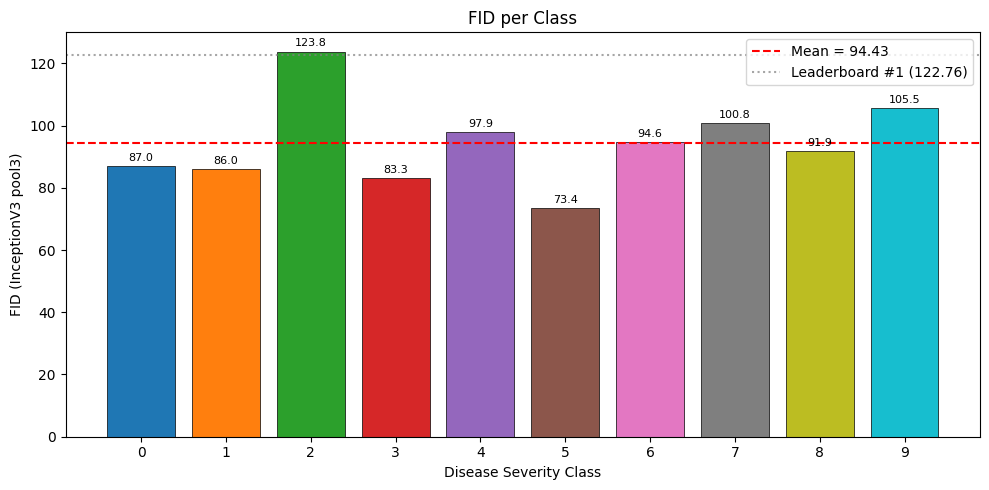

In [15]:
fig, ax = plt.subplots(figsize=(10, 5))

classes = fid_df["class"].values
colors = plt.cm.tab10(np.linspace(0, 1, 10))

bars = ax.bar(classes, fid_df["fid"], color=colors, edgecolor="black", linewidth=0.5)
ax.axhline(fid_df["fid"].mean(), color="red", linestyle="--", label=f'Mean = {fid_df["fid"].mean():.2f}')
ax.axhline(122.76, color="gray", linestyle=":", alpha=0.7, label="Leaderboard #1 (122.76)")
ax.set_xlabel("Disease Severity Class")
ax.set_ylabel("FID (InceptionV3 pool3)")
ax.set_title("FID per Class")
ax.set_xticks(range(10))
ax.legend()
for bar, val in zip(bars, fid_df["fid"]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f"{val:.1f}", ha="center", va="bottom", fontsize=8)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "fid_scores_by_class.png", dpi=150, bbox_inches="tight")
plt.show()

## 2. Temperature Sweep (InceptionV3 FID)

Per-class FID across temperatures 0.50–1.00 for classes 0 to 5. All classes show optimal outcome at temperature 0.6.

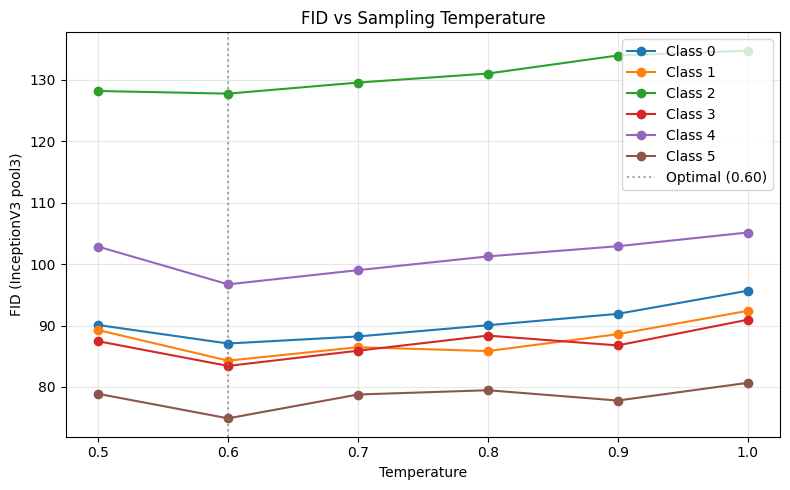

In [ ]:
temperatures = [0.50, 0.60, 0.70, 0.80, 0.90, 1.00]
sweep_data = {
    0: [90.08, 87.07, 88.22, 90.05, 91.90, 95.66],
    1: [89.26, 84.28, 86.47, 85.84, 88.59, 92.39],
    2: [128.21, 127.78, 129.58, 131.05, 133.99, 134.77],
    3: [87.44, 83.42, 85.90, 88.36, 86.76, 90.94],
    4: [102.85, 96.71, 99.02, 101.26, 102.92, 105.15],
    5: [78.87, 74.88, 78.76, 79.46, 77.78, 80.66],
}

fig, ax = plt.subplots(figsize=(8, 5))
for cls, vals in sweep_data.items():
    ax.plot(temperatures, vals, marker="o", markersize=6, label=f"Class {cls}")

ax.axvline(0.60, color="gray", linestyle=":", alpha=0.7, label="Optimal (0.60)")
ax.set_xlabel("Temperature")
ax.set_ylabel("FID")
ax.set_title("FID vs Sampling Temperature")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "temperature_sweep.png", dpi=150, bbox_inches="tight")
plt.show()

## 3. Real vs Generated Sample Images

Displaying false-color RGB composites (bands 60, 30, 10 mapped to R, G, B) for visual comparison.
Three rows: Real, Generated at t=0.60 (best FID), and Generated at t=1.00 (more colorful).

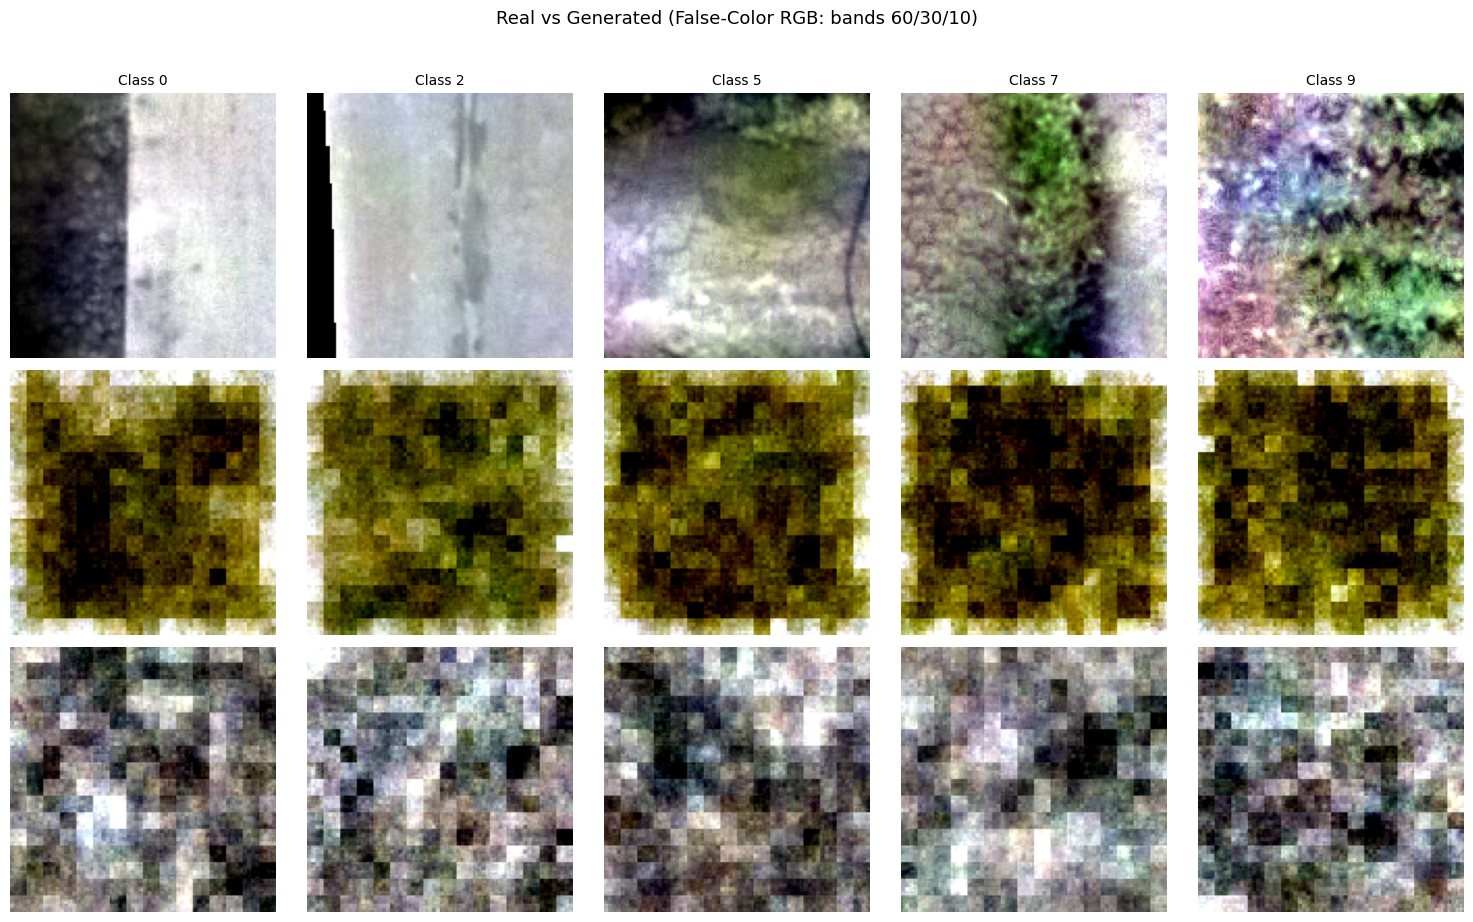

In [ ]:
def load_image_normalized(path):
    arr = np.load(path).astype(np.float32)
    if arr.max() > 1.5:
        arr = (arr - global_min) / (global_max - global_min + 1e-8)
    return np.clip(arr, 0, 1)


def make_rgb(img, bands=(60, 30, 10)):
    rgb = np.stack([img[:, :, b] for b in bands], axis=-1)
    for c in range(3):
        lo, hi = np.percentile(rgb[:, :, c], [2, 98])
        if hi - lo > 1e-6:
            rgb[:, :, c] = np.clip((rgb[:, :, c] - lo) / (hi - lo), 0, 1)
    return rgb


RESULTS_T10_DIR = Path("../results/eval_t1.0")

classes_to_show = [0, 2, 5, 7, 9]
n_show = len(classes_to_show)

fig, axes = plt.subplots(3, n_show, figsize=(3 * n_show, 9))

for col, cls in enumerate(classes_to_show):
    # Real image
    real_dir = DATA_DIR / "evaluation" / str(cls)
    real_files = sorted(real_dir.glob("*.npy"))
    real_img = load_image_normalized(real_files[0])
    axes[0, col].imshow(make_rgb(real_img))
    axes[0, col].set_title(f"Class {cls}", fontsize=10)
    axes[0, col].axis("off")

    # Generated t=0.60
    gen_dir = RESULTS_DIR / "generated" / str(cls)
    gen_files = sorted(gen_dir.glob("*.npy"))
    gen_img = load_image_normalized(gen_files[0])
    axes[1, col].imshow(make_rgb(gen_img))
    axes[1, col].axis("off")

    # Generated t=1.00
    gen_t10_dir = RESULTS_T10_DIR / "generated" / str(cls)
    gen_t10_files = sorted(gen_t10_dir.glob("*.npy"))
    gen_t10_img = load_image_normalized(gen_t10_files[0])
    axes[2, col].imshow(make_rgb(gen_t10_img))
    axes[2, col].axis("off")

axes[0, 0].set_ylabel("Real", fontsize=12, rotation=0, labelpad=40, va="center")
axes[1, 0].set_ylabel("Gen t=0.60", fontsize=11, rotation=0, labelpad=40, va="center")
axes[2, 0].set_ylabel("Gen t=1.00", fontsize=11, rotation=0, labelpad=40, va="center")

plt.suptitle("Real vs Generated (False-Color RGB: bands 60/30/10)", fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "real_vs_generated_samples.png", dpi=150, bbox_inches="tight")
plt.show()

## 4. Spectral Profile Comparison

Mean spectral signature for real vs generated images, per class. This is the most important metric for hyperspectral data, it shows whether the model captures the characteristic absorption/reflection patterns of each disease severity level.

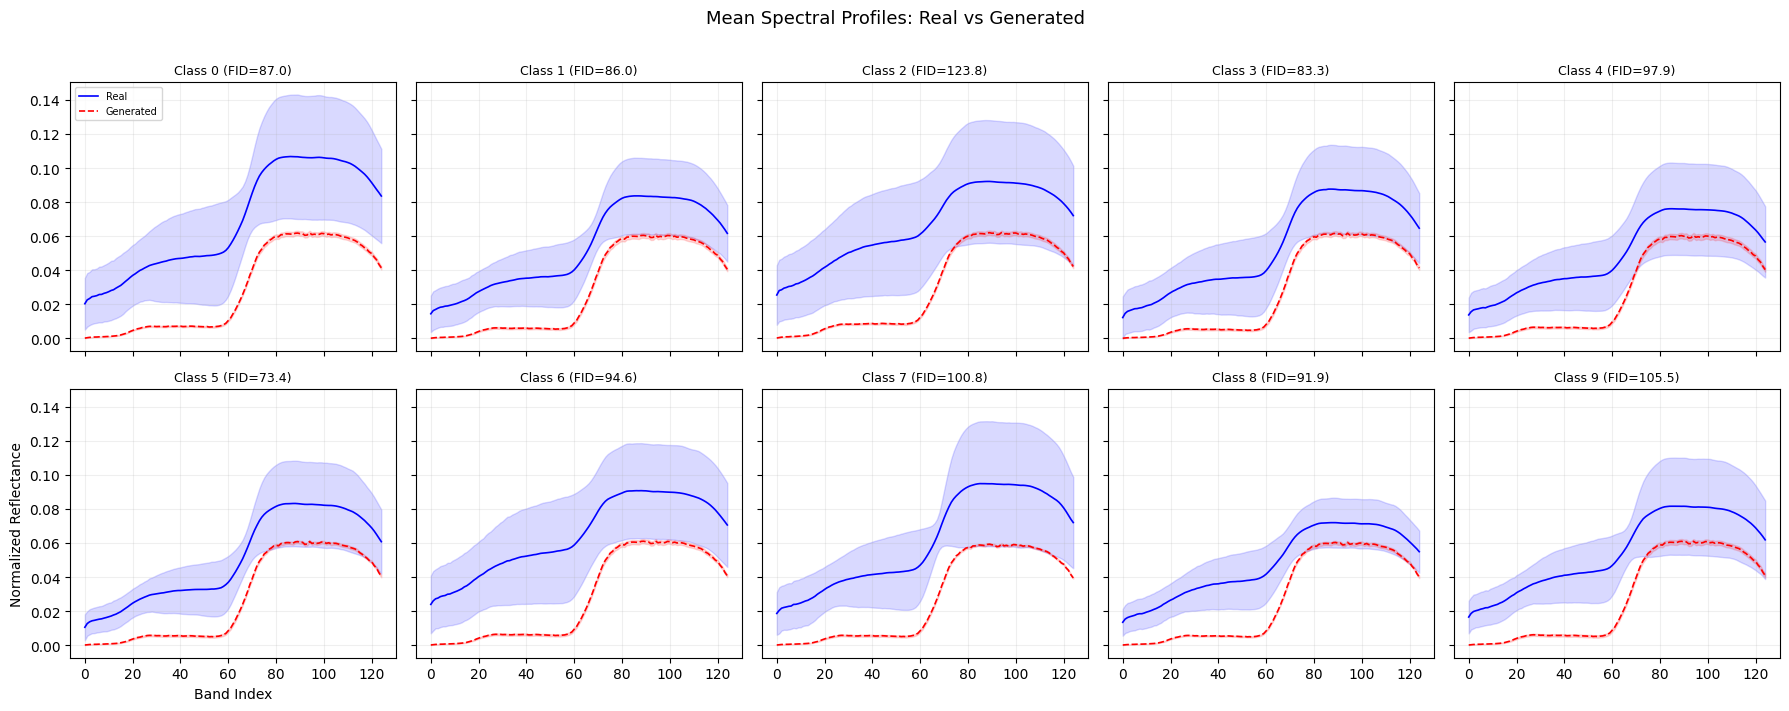

In [13]:
fig, axes = plt.subplots(2, 5, figsize=(18, 7), sharex=True, sharey=True)
bands = np.arange(125)

for cls in range(10):
    ax = axes[cls // 5, cls % 5]

    # Real: load up to 10 images for mean spectrum
    real_dir = DATA_DIR / "evaluation" / str(cls)
    real_files = sorted(real_dir.glob("*.npy"))[:10]
    real_spectra = []
    for f in real_files:
        img = load_image_normalized(f)
        real_spectra.append(img.mean(axis=(0, 1)))  # mean over spatial dims -> (125,)
    real_mean = np.mean(real_spectra, axis=0)
    real_std = np.std(real_spectra, axis=0)

    # Generated: load up to 10 images
    gen_dir = RESULTS_DIR / "generated" / str(cls)
    gen_files = sorted(gen_dir.glob("*.npy"))[:10]
    gen_spectra = []
    for f in gen_files:
        img = load_image_normalized(f)
        gen_spectra.append(img.mean(axis=(0, 1)))
    gen_mean = np.mean(gen_spectra, axis=0)
    gen_std = np.std(gen_spectra, axis=0)

    ax.plot(bands, real_mean, "b-", linewidth=1.2, label="Real")
    ax.fill_between(bands, real_mean - real_std, real_mean + real_std, alpha=0.15, color="blue")
    ax.plot(bands, gen_mean, "r--", linewidth=1.2, label="Generated")
    ax.fill_between(bands, gen_mean - gen_std, gen_mean + gen_std, alpha=0.15, color="red")
    ax.set_title(f"Class {cls} (FID={fid_df.loc[cls, 'fid']:.1f})", fontsize=9)
    ax.grid(True, alpha=0.2)
    if cls == 0:
        ax.legend(fontsize=7)

axes[1, 0].set_xlabel("Band Index")
axes[1, 0].set_ylabel("Normalized Reflectance")
fig.suptitle("Mean Spectral Profiles: Real vs Generated", fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "spectral_profiles.png", dpi=150, bbox_inches="tight")
plt.show()

## 5. Pixel Intensity Distributions

Histogram of pixel values (averaged across all bands) comparing real and generated images for selected classes.

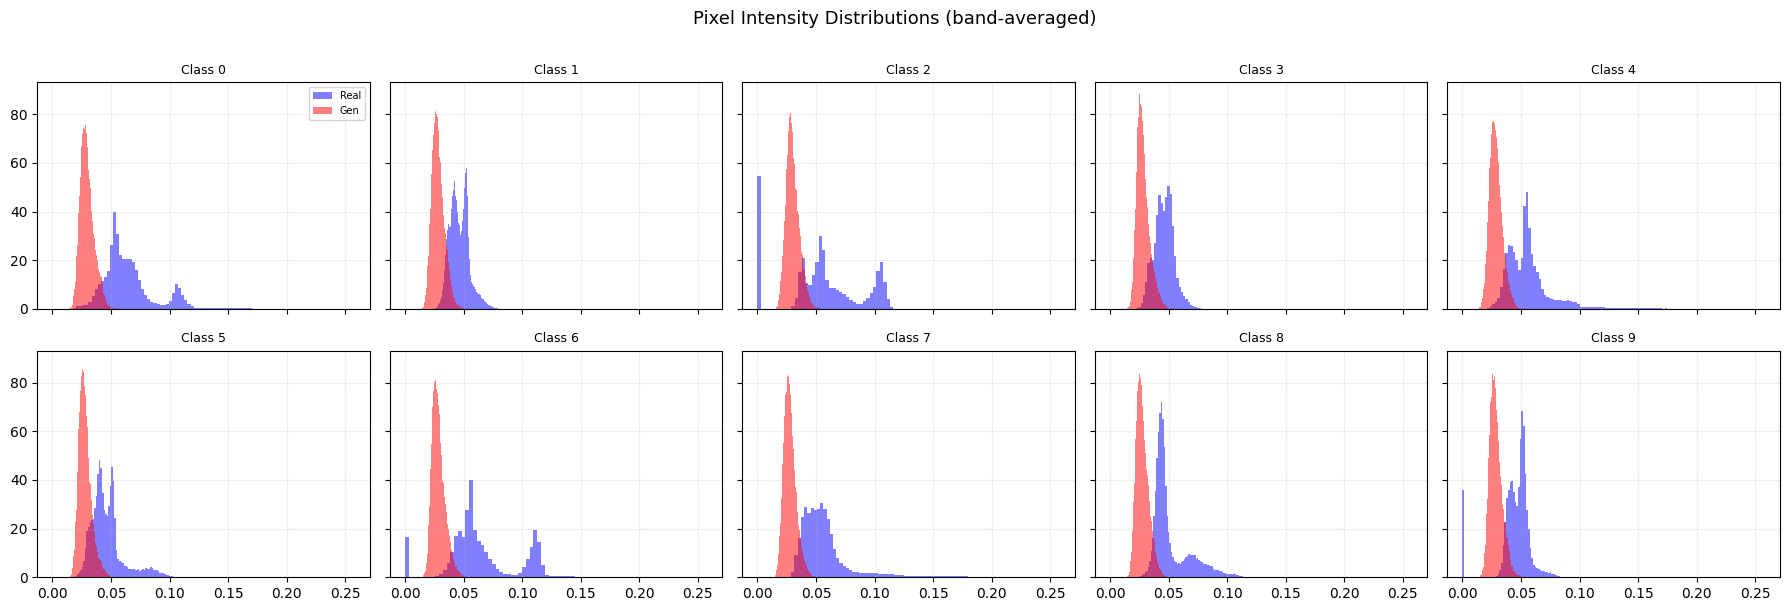

In [14]:
fig, axes = plt.subplots(2, 5, figsize=(18, 6), sharex=True, sharey=True)

for cls in range(10):
    ax = axes[cls // 5, cls % 5]

    # Collect pixel means from a few images
    real_dir = DATA_DIR / "evaluation" / str(cls)
    real_files = sorted(real_dir.glob("*.npy"))[:5]
    real_pixels = np.concatenate([load_image_normalized(f).mean(axis=-1).ravel() for f in real_files])

    gen_dir = RESULTS_DIR / "generated" / str(cls)
    gen_files = sorted(gen_dir.glob("*.npy"))[:5]
    gen_pixels = np.concatenate([load_image_normalized(f).mean(axis=-1).ravel() for f in gen_files])

    ax.hist(real_pixels, bins=80, alpha=0.5, density=True, color="blue", label="Real")
    ax.hist(gen_pixels, bins=80, alpha=0.5, density=True, color="red", label="Gen")
    ax.set_title(f"Class {cls}", fontsize=9)
    ax.grid(True, alpha=0.2)
    if cls == 0:
        ax.legend(fontsize=7)

fig.suptitle("Pixel Intensity Distributions (band-averaged)", fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "pixel_distributions.png", dpi=150, bbox_inches="tight")
plt.show()